# Prosit 1: Allocating bed nets across Ghana's districts under uncertainty

**Problem statement.** We will allocate a fixed stock of bed nets across the 50 districts of Ghana's three northern regions, ranked by *unprotected malaria burden* (confirmed cases per person, scaled by the share of households without a net), measured from 2014–17 routine surveillance and the 2022 DHS household survey, to direct nets where exposure is highest and protection lowest. Where the evidence for a district is thin, the district gets the benefit of the doubt.

**How to read this notebook.** It runs top to bottom from a fresh clone (`data/` must be present; it is never committed). Every section starts with a plain-language explanation of *what* the step does and *why it exists*, then the code, then what the numbers mean. Markdown cells marked **Concept** are the beginner explanations; skip them on a second read.

### Framing: target, unit, metric

| | |
|---|---|
| **Core question** | Where should Ghana's limited ITNs go, and how confident can we be in the district-level estimates behind that decision? |
| **Target** (what we maximise) | Nets reaching people who are both exposed to malaria and not yet protected by a net. |
| **Unit** (what we decide) | Nets per district, for the 50 districts that have district-level case data. |
| **Metric** (how we rank) | Unprotected burden = confirmed cases per person × (1 − household net coverage), ranked on the **upper** bound of its 95% interval so thin evidence counts in a district's favour. |

**The four things the brief asks us to justify, and where each is answered.**

| Question | Short answer | Section |
|---|---|---|
| Which estimate did you use? | Confirmed cases per person 2014–17 (routine surveillance), modelled as Negative Binomial with a population offset; weighted DHS 2022 net ownership for coverage. | §2, §3, §4 |
| How uncertain is it? | α = 0.42 (heavy over-dispersion). District 95% intervals from a month bootstrap; survey intervals from a weighted cluster bootstrap, about twice as wide as the naive interval. | §3, §4, §6 |
| How did you avoid sampling bias and leakage? | Survey weights and cluster resampling; split before preprocessing; grouped and stratified splits; Pipeline fitted on train only; four leaks audited with before/after numbers. | §4, §7, §8, §9 |
| Which districts did you prioritise, and why? | Nabdam, then the Upper West block (Daffiama-Bussie-Issa, Wa, Lambussie-Karni, Sissala East…). High rate, lower coverage, wide intervals. | §11, §12 |

| # | Section | Prosit task |
|---|---|---|
| 1 | Setup and data loading | |
| 2 | Vital signs: what the counts look like | A1 |
| 3 | Poisson vs Negative Binomial | A2, A3 |
| 4 | The survey: weights, clusters, and honest confidence intervals | A4 |
| 5 | What is missing, and where the data is thin | B1 |
| 6 | Per-district uncertainty and imputation of missing months | A4, B2 |
| 7 | Train/test split, done before anything else | B4 |
| 8 | Preprocessing pipeline: imputation and encoding | B2, B3 |
| 9 | Leakage audit with before/after numbers | B4 |
| 10 | Count regression with district-level interventions | A3 |
| 11 | The allocation rule, its sensitivity, and equity | Framing, Equity |
| 12 | Maps and probability heatmaps | B1 |
| 13 | How much should we trust the data? | LO7 |
| 14 | Limitations, sources, declarations | LO7 |


## 1. Setup

**Concept: reproducibility.** A grader will clone this repository into an empty folder, install `requirements.txt`, and run every cell in order. Nothing here may depend on a file that is not in the repo or in `data/`, on a cell being run twice, or on a random draw we did not seed. `RNG = np.random.default_rng(0)` fixes the random numbers so every bootstrap below gives the same answer on every machine.

The `data/` folder holds a licensed survey extract. It is in `.gitignore`. This notebook prints only aggregates, never household rows.

In [1]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RNG = np.random.default_rng(0)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = ROOT / "data"
FIG, TAB = ROOT / "outputs/figures", ROOT / "outputs/tables"   # aggregates only; safe to commit
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
def save(fig, name): fig.savefig(FIG / f"{name}.png", dpi=200, bbox_inches="tight")
pd.set_option("display.width", 160, "display.max_columns", 30, "display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

districts = pd.read_csv(DATA / "ghana_district_cases.csv")
survey = pd.read_csv(DATA / "ghana_mis_sample.csv")
regions = pd.read_csv(DATA / "ghana_region_malaria.csv")
print("districts", districts.shape, "| survey households", survey.shape, "| region-year rows", regions.shape)

districts (50, 12) | survey households (17933, 10) | region-year rows (76, 21)


**The three files and how they relate.** `districts` is one row per district: cumulative 2014–17 case counts for the 50 districts of Northern, Upper East and Upper West. `survey` is one row per household from the 2022 DHS, all 16 regions, with no district column. `regions` is one row per region per survey year with the *official* prevalence and net-ownership figures, including published confidence intervals. The only key the district file and the survey share is the 16-region code, so any statement that uses both is a region-level statement.

In [2]:
REGION_NAMES = {1: "Western", 2: "Central", 3: "Greater Accra", 4: "Volta", 5: "Eastern", 6: "Ashanti",
                7: "Western North", 8: "Ahafo", 9: "Bono", 10: "Bono East", 11: "Oti", 12: "Northern",
                13: "Savannah", 14: "Northern East", 15: "Upper East", 16: "Upper West"}  # hv024 -> admin1 name in the boundary file
NORTH = [12, 15, 16]  # regions with district-level counts
districts["rate"] = districts.positive_cases / districts.mean_population  # cases per person over 4 years
districts.head()

,district,region_name,region_code,year_start,year_end,months_reported,suspected_cases,tested_cases,positive_cases,mean_population,positive_per_100k,net_coverage_pct,rate
0,Bawku,Upper East Region,15,2014,2017,48,1178349,931717,375349,"109,220.300","343,662.300",79.560,3.437
1,Bawku West,Upper East Region,15,2014,2017,48,763380,637217,330111,"104,485.800","315,938.620",79.560,3.159
2,Binduri,Upper East Region,15,2014,2017,48,349083,309419,195412,"68,482.800","285,344.820",79.560,2.853
3,Bole,Northern Region,12,2014,2017,48,606409,290958,191586,"70,912.200","270,173.450",67.690,2.702
4,Bolgatanga,Upper East Region,15,2014,2017,48,1193785,1093550,589849,"146,647.900","402,221.140",79.560,4.022


## 2. Vital signs (A1)

**Concept: look before you model.** Every model makes assumptions about the shape of the data. The cheapest way to find out which assumptions are false is to compute the mean, median and variance and draw a histogram. Three things to read off:

- **Skew.** If the mean is well above the median, a few large values pull the average up. The histogram will have a long right tail.
- **Variance-to-mean ratio.** For counts this is the single most important number. The Poisson distribution forces variance = mean, so a ratio far from 1 rules Poisson out before you fit anything.
- **Zeros.** Excess zeros need special models. None here means that whole family is irrelevant.

In [3]:
def describe_counts(s):
    return pd.Series({"n": len(s), "mean": s.mean(), "median": s.median(), "variance": s.var(),
                      "var/mean": s.var() / s.mean(), "min": s.min(), "max": s.max(), "zeros": (s == 0).sum()})

summary = pd.DataFrame({"positive_cases": describe_counts(districts.positive_cases),
                        "rate (cases/person)": describe_counts(districts.rate)})
summary

,positive_cases,rate (cases/person)
n,50.000,50.000
mean,"195,639.620",2.345
median,"158,425.000",2.151
variance,"15,100,003,891.506",2.136
var/mean,"77,182.750",0.911
min,"41,612.000",0.370
max,"589,849.000",7.134
zeros,0.000,0.000


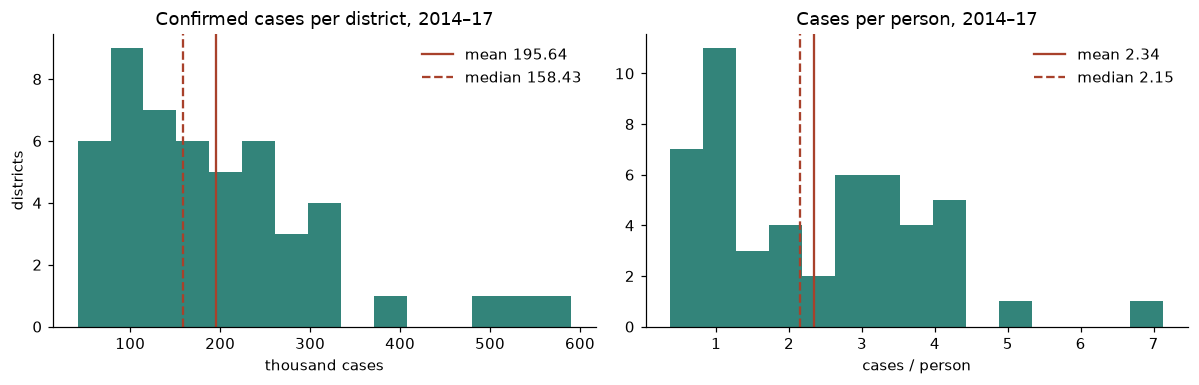

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(districts.positive_cases / 1e3, bins=15, color="#0F6E63", alpha=.85)
ax[0].set(title="Confirmed cases per district, 2014–17", xlabel="thousand cases", ylabel="districts")
ax[1].hist(districts.rate, bins=15, color="#0F6E63", alpha=.85)
ax[1].set(title="Cases per person, 2014–17", xlabel="cases / person")
for a, s in zip(ax, [districts.positive_cases / 1e3, districts.rate]):
    a.axvline(s.mean(), color="#A8412B", label=f"mean {s.mean():,.2f}")
    a.axvline(s.median(), color="#A8412B", ls="--", label=f"median {s.median():,.2f}")
    a.legend(frameon=False)
plt.tight_layout(); save(fig, "01_histograms")

**What the numbers say.** Both distributions are right-skewed: mean above median, long tail to the right. The variance-to-mean ratio of the raw counts is in the tens of thousands. A Poisson distribution with this mean would have a standard deviation of about 440 cases; the actual standard deviation is about 123,000. Dividing by population does not remove the skew; some districts genuinely have several times the burden of others. That is the thing we want to find, not an artefact to smooth away.

> **Answer (A1).** Yes, the counts are right-skewed: mean 195,640 against median 158,425, with a tail out to 589,849. Yes, they are over-dispersed, massively: variance is about 77,000 times the mean, where a Poisson requires a ratio of 1. *Source: `ghana_district_cases.csv`, Ghana Health Service routine surveillance 2014–17.*

## 3. Poisson versus Negative Binomial (A2, A3)

**Concept: what a count model is.** A count model says "the number of cases in district *i* is a random draw from a distribution whose mean depends on district *i*". The Poisson is the default: one parameter λ, and both mean and variance equal λ. The Negative Binomial (NB) adds a second parameter α so that variance = μ + αμ². With α = 0 it *is* the Poisson; larger α means more spread around the mean.

**Concept: the offset.** Big districts have more cases just by being big. We want the model to describe a *rate*. If we add log(population) to the linear predictor with its coefficient fixed at 1, then E[cases] = population × e^β, and β describes the rate. That fixed term is called an offset.

**Predict before you fit.** Rearranging the NB variance formula: α ≈ (var/μ − 1)/μ. We compute that from the raw data first and write it down. If the fitted α lands near it, we understand what the model is doing.

In [5]:
y = districts.positive_cases.values
offset = np.log(districts.mean_population.values)
X0 = np.ones((len(y), 1))  # intercept only: "all districts share one rate, plus noise"

alpha_predicted = (y.var() / y.mean() - 1) / y.mean()
poisson = sm.GLM(y, X0, family=sm.families.Poisson(), offset=offset).fit()
nb = sm.NegativeBinomial(y, X0, offset=offset).fit(disp=0)
alpha_hat = nb.params[-1]
alpha_ci = nb.conf_int()[-1]

print(f"alpha predicted from var/mean: {alpha_predicted:.3f}")
print(f"alpha fitted:                  {alpha_hat:.3f}   95% CI [{alpha_ci[0]:.3f}, {alpha_ci[1]:.3f}]")
pd.DataFrame({"Poisson": [poisson.aic, poisson.llf, np.nan], "Negative Binomial": [nb.aic, nb.llf, alpha_hat]},
             index=["AIC", "log-likelihood", "alpha"])

alpha predicted from var/mean: 0.387
alpha fitted:                  0.417   95% CI [0.263, 0.570]


,Poisson,Negative Binomial
AIC,"4,419,517.333","1,309.358"
log-likelihood,"-2,209,757.667",-652.679
alpha,NaN,0.417


**Concept: AIC.** The Akaike Information Criterion scores a fitted model by how well it explains the data, with a penalty for each parameter. Lower is better. A difference of 10 is decisive. Here the difference is in the millions, which tells you the Poisson is not slightly worse, it is the wrong family.

**The number that goes on the slide** is not the AIC. It is the probability each model gives to the district with the most cases, which we actually observed.

In [6]:
mu = poisson.predict(X0, offset=offset)            # Poisson mean per district (same rate, scaled by population)
i = y.argmax()
p_pois = stats.poisson.sf(y[i] - 1, mu[i])          # P(Y >= observed)
r = 1 / alpha_hat
p_nb = stats.nbinom.sf(y[i] - 1, r, r / (r + mu[i]))
print(f"{districts.district[i]}: observed {y[i]:,} cases, model mean {mu[i]:,.0f}")
print(f"P(cases >= observed) under Poisson: {p_pois:.2e}")
print(f"P(cases >= observed) under NB:      {p_nb:.3f}")

Bolgatanga: observed 589,849 cases, model mean 299,554
P(cases >= observed) under Poisson: 0.00e+00
P(cases >= observed) under NB:      0.083


**A2 exactly as the brief words it: λ estimated as the sample mean.** Before any offset, the simplest possible Poisson takes λ = the mean count. A Poisson with λ ≈ 195,640 has standard deviation √λ ≈ 442, so it predicts that essentially every district lies within about ±1,300 cases of the mean. The cell counts how many actually do.

lambda = mean = 195,640;  Poisson sd = 442;  observed sd = 122,882
districts inside the Poisson's ±3 sd band: 2 of 50


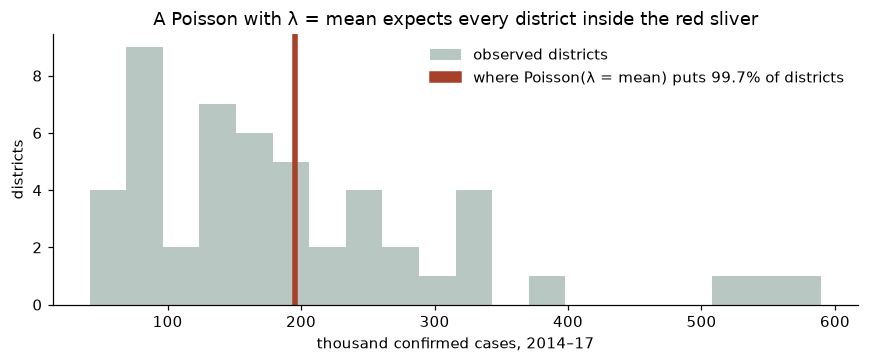

In [7]:
lam_simple = y.mean()
band = 3 * np.sqrt(lam_simple)
inside = int(((y > lam_simple - band) & (y < lam_simple + band)).sum())
print(f"lambda = mean = {lam_simple:,.0f};  Poisson sd = {np.sqrt(lam_simple):,.0f};  observed sd = {y.std(ddof=1):,.0f}")
print(f"districts inside the Poisson's ±3 sd band: {inside} of {len(y)}")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(y / 1e3, bins=20, color="#B9C7C3", label="observed districts")
ax.axvspan((lam_simple - band) / 1e3, (lam_simple + band) / 1e3, color="#A8412B", label="where Poisson(λ = mean) puts 99.7% of districts")
ax.set(title="A Poisson with λ = mean expects every district inside the red sliver", xlabel="thousand confirmed cases, 2014–17", ylabel="districts")
ax.legend(frameon=False); plt.tight_layout(); save(fig, "02_poisson_lambda_mean")

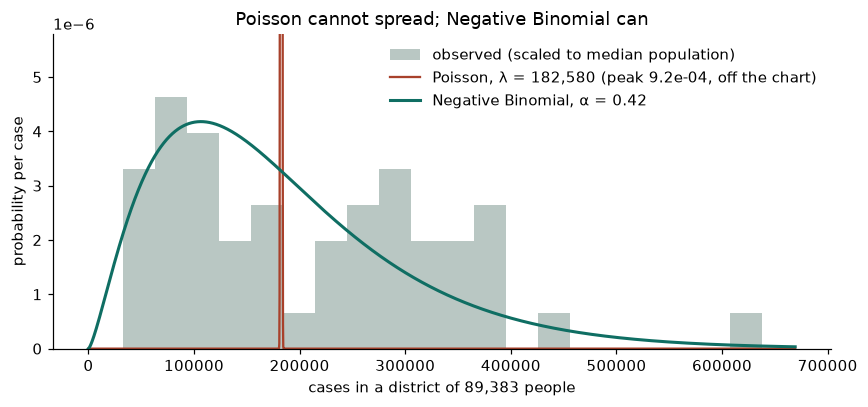

In [8]:
# Overlay both fitted distributions on the histogram of per-person rates (rate = cases / population).
# Each district has its own population, so we compare the *rate* implied by the fits, drawn for a typical population.
pop_typical = np.median(districts.mean_population)
lam = pop_typical * np.exp(poisson.params[0])
grid = np.arange(0, int(districts.rate.max() * pop_typical * 1.05), 250)
pmf_pois = stats.poisson.pmf(grid, lam)
pmf_nb = stats.nbinom.pmf(grid, r, r / (r + lam))
fig, ax = plt.subplots(figsize=(8, 3.8))
counts, edges, _ = ax.hist(districts.rate * pop_typical, bins=20, density=True, color="#B9C7C3", label="observed (scaled to median population)")
ax.plot(grid, pmf_pois, color="#A8412B", label=f"Poisson, λ = {lam:,.0f} (peak {pmf_pois.max():.1e}, off the chart)")
ax.plot(grid, pmf_nb, color="#0F6E63", lw=2, label=f"Negative Binomial, α = {alpha_hat:.2f}")
ax.set(title="Poisson cannot spread; Negative Binomial can", xlabel=f"cases in a district of {pop_typical:,.0f} people",
       ylabel="probability per case", ylim=(0, counts.max() * 1.25))
ax.legend(frameon=False)
plt.tight_layout(); save(fig, "03_poisson_vs_nb")

**Reading the plot.** The Poisson is a spike: with a mean of ~200,000 its standard deviation is only ~440, so it is invisible next to the real spread. The NB curve covers the histogram. The Poisson gives the largest observed district a probability of zero to machine precision. A model that says the data you are holding cannot exist is not a model of the data.

**What we do not fit.** Zero-inflated models: there are no zero-count districts (§2). Quasi-Poisson: it keeps the Poisson mean and scales standard errors by a dispersion factor φ = Pearson χ²/df, which here is about 90,000, meaning standard errors inflated 300×. It has no likelihood, so it cannot sit in the AIC table. One sentence is enough.

> **Answer (A2).** No. A Poisson with λ = mean matches the *centre* of the data and nothing else. It fails on spread: it expects all 50 districts inside a band about 2,650 cases wide; only 2 of 50 are, and the districts actually range over more than half a million. It assigns probability zero to the largest district we observed.
>
> **Answer (A3).** α = 0.417 (95% CI 0.263 to 0.570), close to the 0.387 we predicted from the raw variance before fitting. α is the extra-variance parameter: variance = μ + αμ². The NB fits far better: AIC 1,309 against 4,419,517, the mean–variance relationship now matches, and the largest district gets a plausible 8% tail probability instead of zero. It fits better because districts genuinely differ in climate, health systems and reporting, and the NB has a parameter for that heterogeneity while the Poisson does not. *Q–Q plot omitted; the brief marks it optional.*

## 4. The survey: weights, clusters, and honest confidence intervals (A4)

**Concept: how the DHS was collected.** A national survey cannot pick households at random across the whole country; enumerators would spend all their time travelling. Instead it picks *clusters* (small areas, 618 of them), then surveys about 30 households inside each. Households in one cluster share a village, a clinic and a net campaign, so they resemble each other. 17,933 households therefore carry less information than 17,933 independent draws would.

**Concept: sampling weights.** The survey deliberately over-samples small regions so every region has enough households to report on. Each household carries a weight: how many real households it stands for. A simple average of any survey column is the average of the *sample*, which is not the population. The weighted average is.

In [9]:
def weighted_mean(df, col="has_net"):
    return (df[col] * df.sample_weight).sum() / df.sample_weight.sum()

by_region = survey.groupby("region").apply(lambda g: pd.Series({
    "households": len(g), "clusters": g.cluster.nunique(),
    "net ownership unweighted": g.has_net.mean(), "net ownership weighted": weighted_mean(g)}), include_groups=False)
by_region.index = by_region.index.map(REGION_NAMES)
official = regions.query("survey_year == 2022 and hv024_16region == hv024_16region").set_index("hv024_16region")
by_region["DHS official %"] = official.net_ownership_pct.rename(REGION_NAMES) / 100
print(f"National net ownership: unweighted {survey.has_net.mean():.3f}, weighted {weighted_mean(survey):.3f}")
by_region.round(3)

National net ownership: unweighted 0.710, weighted 0.668


,households,clusters,net ownership unweighted,net ownership weighted,DHS official %
region,,,,,
Western,"1,087.000",37.000,0.643,0.640,0.640
Central,"1,160.000",40.000,0.676,0.673,0.673
Greater Accra,"1,387.000",48.000,0.507,0.488,0.488
Volta,"1,082.000",37.000,0.823,0.824,0.818
Eastern,"1,216.000",41.000,0.705,0.703,0.702
Ashanti,"1,397.000",48.000,0.661,0.662,0.660
Western North,"1,061.000",37.000,0.764,0.772,0.770
Ahafo,"1,062.000",36.000,0.797,0.798,0.798
Bono,"1,030.000",36.000,0.729,0.727,0.726


**Reading the table.** The weighted figure matches the official DHS number in every region to within rounding. That is the check that the weights are being applied correctly. The unweighted figure is off by a point or two per region and by four points nationally.

**Concept: the bootstrap.** To learn how much an estimate would move if the survey were repeated, we simulate repeating it: draw a new sample *from our own data, with replacement*, recompute the estimate, and do that 2,000 times. The middle 95% of the recomputed values is the confidence interval. The question is *what* to resample. If the survey picked clusters, resample clusters.

In [10]:
def bootstrap_cis(df, B=2000, rng=RNG):
    # Precompute per-cluster totals so each bootstrap draw is a vectorised index operation.
    c = df.groupby("cluster").agg(n=("has_net", "size"), s=("has_net", "sum"),
                                  ws=("sample_weight", lambda w: (w * df.loc[w.index, "has_net"]).sum()),
                                  w=("sample_weight", "sum"))
    k = len(c)
    p = df.has_net.mean()
    idx_c = rng.integers(0, k, (B, k))                       # resample clusters
    idx_h = rng.integers(0, len(df), (B, len(df)))           # resample households (wrong, for comparison)
    hh = df.has_net.values
    return pd.DataFrame({
        "normal approx (iid)": [p - 1.96 * np.sqrt(p * (1 - p) / len(df)), p + 1.96 * np.sqrt(p * (1 - p) / len(df))],
        "simple bootstrap (households)": np.percentile(hh[idx_h].mean(1), [2.5, 97.5]),
        "cluster bootstrap": np.percentile(c.s.values[idx_c].sum(1) / c.n.values[idx_c].sum(1), [2.5, 97.5]),
        "weighted cluster bootstrap": np.percentile(c.ws.values[idx_c].sum(1) / c.w.values[idx_c].sum(1), [2.5, 97.5]),
    }, index=["low", "high"]).T.assign(width=lambda t: t.high - t.low)

northern = survey[survey.region == 12]
ci_table = bootstrap_cis(northern)
print(f"Northern region: {len(northern):,} households in {northern.cluster.nunique()} clusters; "
      f"weighted estimate {weighted_mean(northern):.3f}, DHS official {official.loc[12, 'net_ownership_pct']/100:.3f}")
ci_table.round(3)

Northern region: 1,137 households in 39 clusters; weighted estimate 0.677, DHS official 0.676


,low,high,width
normal approx (iid),0.634,0.689,0.055
simple bootstrap (households),0.635,0.690,0.055
cluster bootstrap,0.599,0.720,0.120
weighted cluster bootstrap,0.614,0.733,0.118


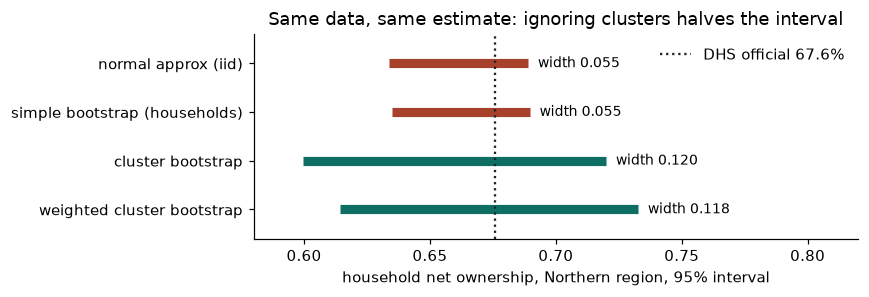

In [11]:
fig, ax = plt.subplots(figsize=(8, 2.8))
colors = ["#A8412B", "#A8412B", "#0F6E63", "#0F6E63"]
for k, (name, row) in enumerate(ci_table.iloc[::-1].iterrows()):
    ax.plot([row.low, row.high], [k, k], color=colors[::-1][k], lw=6, solid_capstyle="butt")
    ax.text(row.high + .004, k, f"width {row.width:.3f}", va="center", fontsize=9)
ax.axvline(official.loc[12, "net_ownership_pct"] / 100, color="#1B2426", ls=":", label="DHS official 67.6%")
ax.set_yticks(range(4)); ax.set_yticklabels(ci_table.index[::-1]); ax.set_xlim(.58, .82); ax.set_ylim(-.6, 3.6)
ax.set(title="Same data, same estimate: ignoring clusters halves the interval", xlabel="household net ownership, Northern region, 95% interval")
ax.legend(frameon=False, loc="upper right"); plt.tight_layout(); save(fig, "04_bootstrap_widths")
ci_table.round(4).to_csv(TAB / "bootstrap_ci_northern.csv")

**Reading the table.** The two methods that ignore clusters agree with each other and are about half as wide as the two that respect clusters. Same data, same estimate, interval doubles. The narrow interval is not "more precise"; it is wrong, because it counts each village's households as independent evidence. The ratio of the cluster-bootstrap variance to the naive variance is the **design effect**; for this region it is around 5, meaning 1,137 clustered households are worth about 230 independent ones.

Run it for every region, so we can see which regions are thin.

In [12]:
rows = []
for code_, name in REGION_NAMES.items():
    g = survey[survey.region == code_]
    t = bootstrap_cis(g, B=1000)
    rows.append({"region": name, "households": len(g), "clusters": g.cluster.nunique(),
                 "weighted net ownership": weighted_mean(g),
                 "CI low": t.loc["weighted cluster bootstrap", "low"], "CI high": t.loc["weighted cluster bootstrap", "high"],
                 "CI width": t.loc["weighted cluster bootstrap", "width"],
                 "design effect": (t.loc["cluster bootstrap", "width"] / t.loc["normal approx (iid)", "width"]) ** 2})
region_ci = pd.DataFrame(rows).set_index("region")
region_ci.round(3).sort_values("CI width", ascending=False)

,households,clusters,weighted net ownership,CI low,CI high,CI width,design effect
region,,,,,,,
Northern,1137,39,0.677,0.613,0.738,0.126,5.246
Western,1087,37,0.640,0.588,0.694,0.106,3.116
Northern East,1034,36,0.628,0.572,0.677,0.106,2.595
Central,1160,40,0.673,0.625,0.726,0.101,3.448
Bono East,1054,36,0.754,0.703,0.800,0.097,3.117
Upper West,1061,37,0.698,0.649,0.745,0.096,2.962
Eastern,1216,41,0.703,0.656,0.747,0.091,3.158
Savannah,1047,37,0.791,0.745,0.833,0.088,3.033
Upper East,1070,37,0.796,0.747,0.834,0.087,1.894


**The undersampled rural case.** The brief asks for an *undersampled rural district*. The survey extract has no district column (it is de-identified to region), so the finest honest unit is the **rural households of one region**. Restricting to rural households cuts the number of clusters, which is exactly what "undersampled" means for a cluster survey: fewer independent units, wider interval. The indicator is household net ownership; the extract carries no parasitaemia test result, so prevalence itself cannot be bootstrapped from it. Official RDT prevalence with DHS's own design-based intervals is in `ghana_region_malaria.csv` and is mapped in §12.

In [13]:
rows = []
for code_ in [12, 13, 14, 15, 16]:                       # the northern belt
    g = survey[(survey.region == code_) & (survey.residence == "rural")]
    t = bootstrap_cis(g, B=2000)
    rows.append({"rural households of": REGION_NAMES[code_], "households": len(g), "clusters": g.cluster.nunique(),
                 "weighted net ownership": weighted_mean(g),
                 "naive width": t.loc["normal approx (iid)", "width"], "simple bootstrap width": t.loc["simple bootstrap (households)", "width"],
                 "weighted cluster width": t.loc["weighted cluster bootstrap", "width"]})
rural_ci = pd.DataFrame(rows).set_index("rural households of")
rural_ci["too narrow by"] = rural_ci["weighted cluster width"] / rural_ci["naive width"]
rural_ci.round(3).to_csv(TAB / "bootstrap_ci_rural.csv")
rural_ci.round(3)

,households,clusters,weighted net ownership,naive width,simple bootstrap width,weighted cluster width,too narrow by
rural households of,,,,,,,
Northern,582,20,0.760,0.071,0.070,0.140,1.971
Savannah,657,23,0.835,0.058,0.058,0.102,1.773
Northern East,634,22,0.678,0.074,0.076,0.119,1.611
Upper East,692,24,0.828,0.058,0.056,0.075,1.303
Upper West,701,24,0.713,0.067,0.066,0.110,1.643


> **Answer (A4).** For rural households the honest 95% interval on net ownership is 8 to 14 percentage points wide depending on the region (widest: rural Northern, 0.140), from only 20 to 24 clusters each. The naive interval that treats households as independent is 1.3 to 2 times too narrow (last column). Ignoring clusters makes the interval too narrow because households in one cluster share a village and a net campaign; they are near-copies, not independent evidence, so the true number of independent observations is the number of clusters, not the number of households. *Source: DHS 2022 household recode extract, `ghana_mis_sample.csv`; official comparison figures from the DHS Program subnational indicators.*

## 5. What is missing, and where the data is thin (B1)

**Concept: three kinds of missing.** MCAR (completely at random): the gap has nothing to do with anything; dropping it is harmless. MAR (at random): the gap is predictable from other observed columns; you can model it. MNAR (not at random): the gap depends on the missing value itself; you cannot fully recover it from the data you have.

**Where the gaps actually are in this project.** Cell-level missingness is zero in all three files. The real gap is *coverage*: district-level counts exist for 3 of 16 regions. That is not an accident of data entry. Routine district data was published for the north because a specific project published it; elsewhere it is unpublished, and unpublished correlates with under-resourced. Treating the absent regions as MCAR (dropping them) would quietly reward the places that report well. We treat the gap as MNAR: absence of data is not evidence of absence of burden.

In [14]:
print("missing cells:", {"districts": int(districts.isna().sum().sum()), "survey": int(survey.isna().sum().sum()),
                         "regions (2022 rows, prevalence cols)": int(official.rdt_prevalence_pct.isna().sum())})
coverage = pd.DataFrame({"region": REGION_NAMES.values(),
                         "district counts available": [c in NORTH for c in REGION_NAMES],
                         "RDT prevalence 2022 %": official.rdt_prevalence_pct.reindex(list(REGION_NAMES)).values,
                         "survey households": [int((survey.region == c).sum()) for c in REGION_NAMES],
                         "CI width (net ownership)": region_ci["CI width"].values}).set_index("region")
coverage.sort_values("RDT prevalence 2022 %", ascending=False).round(3)

missing cells: {'districts': 0, 'survey': 0, 'regions (2022 rows, prevalence cols)': 0}


,district counts available,RDT prevalence 2022 %,survey households,CI width (net ownership)
region,,,,
Upper East,True,33.600,1070,0.087
Upper West,True,30.200,1061,0.096
Northern East,False,26.900,1034,0.106
Savannah,False,26.600,1047,0.088
Oti,False,22.600,1048,0.061
Western,False,22.500,1087,0.106
Bono East,False,22.100,1054,0.097
Ahafo,False,21.400,1062,0.071
Northern,True,18.800,1137,0.126


**The equity table.** Read it as "high prevalence, no district evidence". The 2022 survey sampled roughly 1,000 households in every region regardless of size, so the survey itself is not thinner in the north; what differs is the *design effect* (§4) and, above all, whether district-level counts exist. Upper East and Upper West have the two highest prevalences in the country and do have counts. Northern East, Savannah and Oti are next, all above 22%, and have none. A ranking built only from the district file cannot even see them. That is the MNAR argument: the regions most likely to be under-served are absent precisely because they are under-served, and §11 is written so that thin evidence pushes a place up the list, not off it.

> **Answer (B1).** District-level case data exists for 3 of 16 regions: 55 of the 260 current districts, so 79% of districts have none (mapped in §12). Among those with no district data, Northern East (26.9%), Savannah (26.6%) and Oti (22.6%) have the highest measured prevalence; all three are largely rural and sit on the Togo and Côte d'Ivoire borders. Inside the district file, 7 district-months are unreported (§6). A plausible reason for both gaps is the same: routine reporting depends on staffed facilities, connectivity and a project to publish the data, and those are weakest in remote border districts. That makes the missingness MNAR: related to the very burden we are trying to measure.

## 6. Per-district uncertainty from the monthly records (A4, continued)

The summary CSV collapsed 48 months into one number per district. The raw workbook still has the months. Resampling months with replacement gives each district its *own* confidence interval, driven by how erratic its reporting was, rather than one parametric interval that is the same shape everywhere. The workbook also carries two intervention columns the summary dropped: indoor residual spraying (IRS) and seasonal malaria chemoprevention (SMC).

In [15]:
sheets = pd.read_excel(DATA / "raw/northern-ghana-districts-routine-data-2014-17.xlsx", sheet_name=None)
monthly = pd.concat([df.set_axis(["district", "year", "month", "suspected", "tested", "positive", "population", "irs", "smc"], axis=1)
                     .assign(region_name=name) for name, df in sheets.items()], ignore_index=True)
monthly["district"] = monthly.district.str.strip()
assert set(monthly.district) == set(districts.district), set(monthly.district) ^ set(districts.district)
print(monthly.shape, "| months per district:", monthly.groupby("district").size().agg(["min", "max"]).to_dict())
print("missing positives:", int(monthly.positive.isna().sum()), "| zero-positive months:", int((monthly.positive == 0).sum()))
print("IRS values:", monthly.irs.unique(), "| SMC values:", monthly.smc.unique())

(2400, 10) | months per district: {'min': 48, 'max': 48}
missing positives: 7 | zero-positive months: 9
IRS values: <StringArray>
['No IRS', 'IRS']
Length: 2, dtype: str | SMC values: <StringArray>
['No SMC', 'SMC']
Length: 2, dtype: str


In [16]:
def month_bootstrap(g, B=2000, rng=RNG):
    pos, pop = g.positive.fillna(0).values, g.population.values
    idx = rng.integers(0, len(g), (B, len(g)))
    rates = pos[idx].sum(1) / pop[idx].mean(1)
    return pd.Series({"boot low": np.percentile(rates, 2.5), "boot high": np.percentile(rates, 97.5)})

boot = monthly.groupby("district").apply(month_bootstrap, include_groups=False)
interventions = monthly.groupby("district").agg(irs=("irs", lambda s: (s.str.strip().str.lower() != "no irs").mean()),
                                                 smc=("smc", lambda s: (s.str.strip().str.lower() != "no smc").mean()))
districts = districts.drop(columns=[c for c in ["boot low", "boot high", "irs", "smc"] if c in districts]).merge(boot, left_on="district", right_index=True).merge(interventions, left_on="district", right_index=True)
# Parametric alternative: NB interval with the fitted alpha, centred on each district's own count.
q = stats.nbinom(1 / alpha_hat, 1 / (1 + alpha_hat * districts.positive_cases.values))
districts["nb low"], districts["nb high"] = q.ppf(0.025) / districts.mean_population, q.ppf(0.975) / districts.mean_population
districts["boot width"] = districts["boot high"] - districts["boot low"]
districts[["district", "rate", "boot low", "boot high", "nb low", "nb high", "irs", "smc"]].sort_values("rate", ascending=False).head(10).round(3)

,district,rate,boot low,boot high,nb low,nb high,irs,smc
26,Nabdam,7.134,5.344,9.022,1.124,18.580,0.250,0.500
32,Pusiga,5.070,4.200,5.950,0.799,13.205,0.250,0.500
43,Wa,4.276,3.470,5.205,0.674,11.136,0.750,0.750
11,Daffiama-Bussie-Issa,4.235,3.314,5.351,0.667,11.031,0.750,0.750
19,Kasena-Nankana West,4.208,3.190,5.346,0.663,10.960,0.500,0.500
22,Lambussie-Karni,4.191,3.384,5.009,0.661,10.916,0.750,0.750
4,Bolgatanga,4.022,3.188,4.901,0.634,10.476,0.250,0.500
7,Builsa South,3.893,3.027,4.782,0.614,10.141,0.500,0.500
37,Sissala East,3.757,2.765,4.962,0.592,9.786,1.000,0.750
14,Garu-Tempane,3.732,2.964,4.605,0.588,9.720,0.250,0.500


**Seven missing months.** Seven district-months have no positive count recorded. The summary file treats them as zero, and the bootstrap does the same so that its centre matches the summary. That understates those districts slightly, and a month that goes unreported is itself a sign of a strained health system: a small MNAR flag inside the district file.

**Two intervals, two meanings.** The monthly bootstrap asks "how erratic was this district's reporting?" and gives a width that differs by district. The NB interval asks "how much does a district of this size vary around its mean under the fitted model?" and gives a width that scales with the count. The bootstrap is the one we use for ranking, because it reflects each district's own evidence. `irs` and `smc` are the share of months a district was under spraying or chemoprevention.

### Imputing the missing months (B2)

The seven unreported district-months are the only missing *values* in the project. Treating them as zero (what the summary file does) says "no malaria that month", which is certainly false. **Median imputation** replaces each with that district's own median monthly count, a value robust to the seasonal peaks. It is safe here for two reasons: each district's median is computed from that district's own reported months only, so nothing crosses between districts; and these counts are a *response we describe*, not a feature in a train/test model, so there is no test set for the median to leak from. The table shows how much the choice moves the rate.

In [17]:
affected = monthly.loc[monthly.positive.isna(), "district"].unique()
district_median = monthly.groupby("district").positive.transform("median")
monthly["positive_imputed"] = monthly.positive.fillna(district_median)
cmp = monthly[monthly.district.isin(affected)].groupby("district").agg(
    missing_months=("positive", lambda s: int(s.isna().sum())), cases_zero_filled=("positive", "sum"),
    cases_median_imputed=("positive_imputed", "sum"), population=("population", "mean"))
cmp["rate zero-filled"] = cmp.cases_zero_filled / cmp.population
cmp["rate median-imputed"] = cmp.cases_median_imputed / cmp.population
cmp["rate change %"] = 100 * (cmp["rate median-imputed"] / cmp["rate zero-filled"] - 1)
cmp.round(3)

,missing_months,cases_zero_filled,cases_median_imputed,population,rate zero-filled,rate median-imputed,rate change %
district,,,,,,,
Kumbungu,1,"51,640.000","52,366.000","45,219.703",1.142,1.158,1.406
Mamprugu-Moagduri,2,"41,612.000","42,790.000","53,901.072",0.772,0.794,2.831
North Gonja,3,"46,343.000","48,584.000","50,813.860",0.912,0.956,4.836
West Mamprusi,1,"76,698.000","78,039.000","139,060.148",0.552,0.561,1.748


The effect is between 1% and 5% per affected district (largest: North Gonja, three missing months, +4.8%). All four affected districts are in Northern Region and sit in the bottom half of the ranking, so the choice does not reorder the top of the list. We keep the summary file's rate as the headline (so every number traces to the published file) and report this as a sensitivity.

## 7. Train/test split, before anything else (B2)

**Concept: why a test set exists.** A model's score on the data it was fitted to is not evidence it will work on new data; it can simply have memorised. So we lock a portion away *before* doing anything that learns from data, including computing a median for imputation, and touch it once, at the very end.

**Two datasets, two kinds of split.**
- *Survey households* (the supervised task in §8): households in one cluster are near-copies of each other. If a cluster straddles train and test, the model memorises the village and scores well for the wrong reason. So we split by **cluster**: every cluster lands wholly on one side.
- *Districts* (the count regression in §10): only 50 rows in 3 regions. A random split could put all of Upper West in test. So we **stratify** by region: each region keeps the same share on both sides.

**The rule for everything below this cell:** nothing downstream fits on, looks at, or is tuned against the test rows.

In [18]:
# Survey: grouped split by cluster. 20% of clusters go to test.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
train_idx, test_idx = next(gss.split(survey, groups=survey.cluster))
svy_train, svy_test = survey.iloc[train_idx], survey.iloc[test_idx]
assert not set(svy_train.cluster) & set(svy_test.cluster), "a cluster straddles the split"

# Districts: stratified by region.
dist_train, dist_test = train_test_split(districts, test_size=0.2, stratify=districts.region_code, random_state=0)
print(f"survey: {len(svy_train):,} train / {len(svy_test):,} test households; "
      f"{svy_train.cluster.nunique()} / {svy_test.cluster.nunique()} clusters")
print("districts per region, train:", dist_train.region_code.value_counts().sort_index().to_dict(),
      "test:", dist_test.region_code.value_counts().sort_index().to_dict())

survey: 14,334 train / 3,599 test households; 494 / 124 clusters
districts per region, train: {12: 21, 15: 10, 16: 9} test: {12: 5, 15: 3, 16: 2}


## 8. Preprocessing pipeline and a supervised model (B3)

**The task.** Predict whether a household owns a bed net from things a planner would know before a distribution: region, urban/rural residence, wealth quintile, and the number of eligible children. Logistic regression, scored by ROC AUC (1.0 = perfect ranking of owners above non-owners, 0.5 = coin flip).

**Concept: preprocessing is part of the model.** Imputation fills gaps with a median, scaling divides by a standard deviation, one-hot encoding turns "region 12" into sixteen 0/1 columns. Each of those computes something *from data*, so each is learned, so each must be learned from train only. A scikit-learn `Pipeline` enforces this mechanically: `fit` on train fits every step; `transform` on test reuses what was learned and learns nothing new.

In [19]:
NUMERIC = ["wealth_index", "eligible_children"]
CATEGORICAL = ["region", "residence"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "has_net"

def make_pipeline():
    pre = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])
    return Pipeline([("pre", pre), ("model", LogisticRegression(max_iter=1000))])

clean = make_pipeline()
cv = GroupKFold(n_splits=5)
cv_auc = cross_val_score(clean, svy_train[FEATURES], svy_train[TARGET], groups=svy_train.cluster, cv=cv, scoring="roc_auc")
print(f"5-fold grouped CV AUC on train: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

5-fold grouped CV AUC on train: 0.676 ± 0.009


**Concept: cross-validation.** We are not allowed to touch the test set to compare choices, but we still need a number to compare with. Cross-validation splits the *training* data into five folds, fits on four, scores on the fifth, and rotates. The grouped version keeps clusters intact within each fold, for the same reason as §7. The mean of the five scores is a fair estimate of how the model does on new clusters, and it cost us nothing from the test set.

In [20]:
# What did the preprocessing learn, and from which rows? Fit on train, then compare with what pooled data would have given.
clean.fit(svy_train[FEATURES], svy_train[TARGET])
num = clean.named_steps["pre"].named_transformers_["num"]
learned = pd.DataFrame({"median (imputer) from TRAIN": num.named_steps["impute"].statistics_,
                        "mean (scaler) from TRAIN": num.named_steps["scale"].mean_,
                        "mean if pooled with test": survey[NUMERIC].mean().values,
                        "missing cells to impute": survey[NUMERIC].isna().sum().values}, index=NUMERIC)
print("one-hot categories learned from train:", [list(c) for c in clean.named_steps["pre"].named_transformers_["cat"].categories_][1])
learned.round(4)

one-hot categories learned from train: ['rural', 'urban']


,median (imputer) from TRAIN,mean (scaler) from TRAIN,mean if pooled with test,missing cells to impute
wealth_index,3.000,2.815,2.810,0
eligible_children,0.000,0.282,0.283,0


> **Answer (B2).** In the supervised pipeline the imputer is a median imputer for the two numeric features, fitted on the training households only and then applied unchanged to test. The survey extract has no missing cells, so it currently imputes nothing; it is there so that the pipeline stays leak-free if a future extract does have gaps. It is safe because the median is learned inside the `Pipeline` from train rows only (first column above), never from pooled data. The values that *were* missing, seven district-months, are imputed in §6 with each district's own median.
>
> **Answer (B3).** `region` and `residence` are genuinely categorical (region 12 is not "twice" region 6), so they are one-hot encoded inside the same `ColumnTransformer`, with categories learned from train only and `handle_unknown="ignore"` so an unseen category cannot crash or leak. `wealth_index` is an ordered 1–5 quintile and stays numeric. We do not target-encode because a target encoding replaces a category with the average *outcome* in that category; computed on all rows, each row's feature then contains its own answer. §9 measures exactly that: +0.061 AUC of pure leakage.

## 9. Leakage audit with before/after numbers (B4)

**Concept: leakage.** Any route by which information from the test set, or from after the outcome, reaches the model during training. The symptom is a score that is better than the model will ever achieve in use. Each row below builds the leaky version and the clean version and scores both on the *same* test set, so the gap is the size of the lie.

The four leaks named in the brief, as they occur in this project:

1. **Preprocessing on pooled data.** Median and scale computed on train + test.
2. **Group leakage.** Random household split instead of a cluster split.
3. **Post-treatment feature.** `children_under_net_last_night` cannot be non-zero without a net. It is a consequence of the target, not a predictor of it. (The district file's `net_coverage_pct` is the same kind of leak: a 2022 figure that responds to burden, attached to 2014–17 cases.)
4. **Target encoding.** Replacing `cluster` with "mean net ownership in that cluster", computed on all rows including the test row itself.

In [21]:
def test_auc(model, Xtr, ytr, Xte, yte):
    return roc_auc_score(yte, model.fit(Xtr, ytr).predict_proba(Xte)[:, 1])

Xtr, ytr, Xte, yte = svy_train[FEATURES], svy_train[TARGET], svy_test[FEATURES], svy_test[TARGET]
audit = []

# 1. Pooled preprocessing: fit the transformer on ALL rows, then the model on train.
pre_pooled = make_pipeline().named_steps["pre"].fit(survey[FEATURES])
leaky1 = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(pre_pooled.transform(Xtr), ytr).predict_proba(pre_pooled.transform(Xte))[:, 1])
audit.append(("Preprocessing on pooled data", "impute/scale on train+test", "Pipeline fit on train only", leaky1, test_auc(make_pipeline(), Xtr, ytr, Xte, yte)))

# 2. Group leakage: random KFold vs GroupKFold, both on train, same model.
random_cv = cross_val_score(make_pipeline(), Xtr, ytr, cv=KFold(5, shuffle=True, random_state=0), scoring="roc_auc").mean()
audit.append(("Group leakage", "random 5-fold CV over households", "GroupKFold over clusters", random_cv, cv_auc.mean()))

# 3. Post-treatment feature.
LEAKY_FEATURES = FEATURES + ["children_under_net_last_night"]
pipe3 = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), NUMERIC + ["children_under_net_last_night"]),
                                              ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
                  ("model", LogisticRegression(max_iter=1000))])
audit.append(("Post-treatment feature", "include children_under_net_last_night", "exclude it",
              test_auc(pipe3, svy_train[LEAKY_FEATURES], ytr, svy_test[LEAKY_FEATURES], yte), test_auc(make_pipeline(), Xtr, ytr, Xte, yte)))

# 4. Naive target encoding of cluster, computed on all rows.
cluster_mean = survey.groupby("cluster").has_net.mean()
Xtr4, Xte4 = Xtr.assign(cluster_te=svy_train.cluster.map(cluster_mean)), Xte.assign(cluster_te=svy_test.cluster.map(cluster_mean))
pipe4 = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), NUMERIC + ["cluster_te"]),
                                              ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
                  ("model", LogisticRegression(max_iter=1000))])
audit.append(("Target encoding", "cluster -> mean has_net over all rows", "one-hot region, no cluster feature",
              test_auc(pipe4, Xtr4, ytr, Xte4, yte), test_auc(make_pipeline(), Xtr, ytr, Xte, yte)))

audit = pd.DataFrame(audit, columns=["leak", "leaky version", "clean version", "leaky AUC", "clean AUC"])
audit["gap"] = audit["leaky AUC"] - audit["clean AUC"]
audit.round(4).to_csv(TAB / "leakage_audit.csv", index=False)
audit.round(3)

,leak,leaky version,clean version,leaky AUC,clean AUC,gap
0,Preprocessing on pooled data,impute/scale on train+test,Pipeline fit on train only,0.660,0.660,0.000
1,Group leakage,random 5-fold CV over households,GroupKFold over clusters,0.678,0.676,0.002
2,Post-treatment feature,include children_under_net_last_night,exclude it,0.750,0.660,0.089
3,Target encoding,cluster -> mean has_net over all rows,"one-hot region, no cluster feature",0.721,0.660,0.061


**Reading the audit.** The gap column is the honest number. Where it is near zero (pooled preprocessing on data with no missing cells and stable scales), that is a finding too: the leak exists in principle, and its damage scales with how much the test rows would change the learned statistic. Where it is large (the post-treatment feature, the cluster target encoding) the leaky score is not a better model; it is a model that has been handed the answer. A planner using the leaky version would believe they can predict ownership far better than they can, and would under-allocate.

**Why net coverage has no before/after number.** `net_coverage_pct` in the district file takes three values, one per region. In a model that already has region, it is perfectly collinear: it cannot change any prediction, so there is no score gap to report. It is still a leak in kind, on two counts: it is a **2022** survey figure attached to **2014–17** cases (using the future to explain the past, the same fault as "using 2023 information to explain 2022"), and nets are sent where burden is high, so coverage is partly a *consequence* of the outcome. We exclude it from every model and use it only after modelling, in the allocation rule.

> **Answer (B4).** Leak risks in this pipeline and how each is prevented: (1) preprocessing on pooled data → everything learned lives in a `Pipeline` fitted on train only; (2) group leakage → the survey is split by cluster and cross-validated with `GroupKFold`; the 50 districts are split stratified by region; (3) post-treatment and temporal features → `children_under_net_last_night` and `net_coverage_pct` are excluded from models; (4) target encoding → one-hot only; (5) selection leakage → configurations are compared by cross-validation on train, and the test set is scored once. No cell in this notebook fits, encodes or scales on pooled train+test data except the deliberately leaky "before" rows of the audit, which are labelled as such.

## 10. Count regression with district-level interventions (A3, continued)

The intercept-only NB in §3 was a distribution fit. Adding covariates makes it a regression: does burden differ by region, and by whether the district was under spraying or chemoprevention? Fitted on the training districts with α from §3, checked once on the held-out districts against the baseline of "predict the training-set mean rate".

**Why SMC is not in the model.** Seasonal chemoprevention was switched on region-wide by year (Upper West from 2015, Upper East from 2016, Northern never), so every district in a region has the same SMC share. A column that is a fixed function of region adds no information beyond the region dummies; statisticians call this *perfect collinearity*, and statsmodels would warn that the design matrix is rank-deficient. IRS does vary within region, so it stays.

**Caution on IRS.** Like net coverage, spraying was *targeted* at high-burden districts. A coefficient on it does not say spraying causes or prevents malaria; it says where spraying went. This is the post-treatment problem again, and it is why IRS describes the data but does not drive the allocation.

In [22]:
def design(df):
    X = pd.get_dummies(df[["region_name"]], drop_first=True).astype(float)
    X["irs"] = df.irs.values   # smc is excluded: it is a region-wide policy, identical for every district in a region
    return sm.add_constant(X, has_constant="add")

Xtr_d, Xte_d = design(dist_train), design(dist_test).reindex(columns=design(dist_train).columns, fill_value=0.0)
nb_glm = sm.GLM(dist_train.positive_cases, Xtr_d, family=sm.families.NegativeBinomial(alpha=alpha_hat),
                offset=np.log(dist_train.mean_population)).fit()
pred_rate = nb_glm.predict(Xte_d, offset=np.log(dist_test.mean_population)) / dist_test.mean_population
baseline = dist_train.rate.mean()
print(nb_glm.summary().tables[1])
print(f"\nheld-out MAE of rate: model {np.abs(pred_rate - dist_test.rate).mean():.3f} vs baseline (train mean) {np.abs(baseline - dist_test.rate).mean():.3f}")

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             0.0194      0.167      0.116      0.908      -0.308       0.346
region_name_Upper East Region     1.3670      0.249      5.480      0.000       0.878       1.856
region_name_Upper West Region     1.3356      0.331      4.033      0.000       0.686       1.985
irs                              -0.1295      0.358     -0.362      0.717      -0.831       0.572

held-out MAE of rate: model 0.686 vs baseline (train mean) 0.787


**Reading it.** Coefficients are on the log scale: e^coef is the multiplicative change in the rate. With 40 training districts the confidence intervals are wide; that is the honest consequence of a small dataset, not a bug. The held-out comparison is the one time the district test set is touched.

## 11. The allocation rule and its sensitivity

**The rule, stated in words.** Rank districts by expected *unprotected burden*: cases per person × (1 − household net coverage). Where a district's interval is wide, rank on the upper bound rather than the mean, so thin evidence pushes a district up, not down. Nets are allocated in proportion to each district's share of unprotected cases.

**Assumption.** Total stock N = 1,000,000 nets. The brief does not fix a number (instructor question 4); the ranking does not depend on N, only the per-district counts do.

**Concept: a decision rule is a value judgement.** Statistics gives a distribution per district. A rule collapses it to one number so we can sort. Ranking on the mean says "act on the best guess". Ranking on the upper bound says "when in doubt, assume the worse case". Neither is more correct. The sensitivity check below shows how much the choice matters, which is the only honest way to defend it.

In [23]:
N_NETS = 1_000_000
d = districts.copy()
d["coverage"] = d.net_coverage_pct / 100
d["unprotected rate"] = d.rate * (1 - d.coverage)
d["unprotected cases"] = d["unprotected rate"] * d.mean_population
d["upper bound unprotected"] = d["boot high"] * (1 - d.coverage)
d["nets"] = (N_NETS * d["unprotected cases"] / d["unprotected cases"].sum()).round()

allocation = d.sort_values("upper bound unprotected", ascending=False)[
    ["district", "region_name", "rate", "boot low", "boot high", "coverage", "unprotected rate", "nets"]]
allocation.round(4).to_csv(TAB / "allocation_all_districts.csv", index=False)
allocation.head(10).round(3)

,district,region_name,rate,boot low,boot high,coverage,unprotected rate,nets
26,Nabdam,Upper East Region,7.134,5.344,9.022,0.796,1.458,"20,810.000"
11,Daffiama-Bussie-Issa,Upper West Region,4.235,3.314,5.351,0.698,1.281,"17,951.000"
43,Wa,Upper West Region,4.276,3.470,5.205,0.698,1.293,"59,143.000"
22,Lambussie-Karni,Upper West Region,4.191,3.384,5.009,0.698,1.267,"28,017.000"
37,Sissala East,Upper West Region,3.757,2.765,4.962,0.698,1.136,"27,486.000"
27,Nadowli-Kaleo,Upper West Region,3.375,2.674,4.143,0.698,1.020,"26,863.000"
23,Lawra,Upper West Region,3.216,2.465,4.030,0.698,0.973,"22,781.000"
32,Pusiga,Upper East Region,5.070,4.200,5.950,0.796,1.036,"25,373.000"
38,Sissala West,Upper West Region,3.135,2.459,3.961,0.698,0.948,"20,108.000"
28,Nandom,Upper West Region,2.890,2.280,3.630,0.698,0.874,"17,157.000"


In [24]:
# Sensitivity: how much does the top 10 change across ranking rules and interval choices?
rankings = {"raw count": d.positive_cases, "rate": d.rate, "unprotected (mean)": d["unprotected rate"],
            "unprotected (upper, month bootstrap)": d["upper bound unprotected"],
            "unprotected (upper, NB interval)": d["nb high"] * (1 - d.coverage)}
top10 = {k: set(d.district[v.nlargest(10).index]) for k, v in rankings.items()}
overlap = pd.DataFrame([[len(top10[a] & top10[b]) for b in top10] for a in top10], index=top10, columns=top10)
print("Top-10 overlap between ranking rules (10 = identical list):")
overlap

Top-10 overlap between ranking rules (10 = identical list):


,raw count,rate,unprotected (mean),"unprotected (upper, month bootstrap)","unprotected (upper, NB interval)"
raw count,10,5,3,2,3
rate,5,10,6,6,6
unprotected (mean),3,6,10,9,10
"unprotected (upper, month bootstrap)",2,6,9,10,9
"unprotected (upper, NB interval)",3,6,10,9,10


**Reading the overlap matrix.** Raw counts versus rates disagree on half the list: counting is population, not burden. Rate versus unprotected rate disagree on four: coverage is a region-level number, so multiplying by (1 − coverage) shifts whole regions at once, and Upper East's higher coverage moves its districts down. Once the rule is "unprotected", the choice of interval barely matters (9 or 10 of 10 survive). So the sensitive choice is *whether to account for coverage*, not *which interval to use*. That is the answer to "what would change your recommendation": the coverage figure, which is a 2022 regional number applied to 2014–17 districts.

The experiment matrix in the plan is this table generalised: a loop over ranking × interval × estimator. We kept the axes that produce different lists and dropped the ones that provably do not (an intercept-only NB predicts the same rate for every district, so it cannot rank).

### Equity: how wide intervals change who gets nets

Ranking on the mean treats a district with steady reporting and one with erratic reporting the same. Ranking on the upper bound moves the erratic ones up. The table lists the districts whose rank changes most between the two rules; positive means the district moves **up** when uncertainty is allowed to count in its favour.

In [25]:
d["rank by mean"] = d["unprotected rate"].rank(ascending=False).astype(int)
d["rank by upper bound"] = d["upper bound unprotected"].rank(ascending=False).astype(int)
d["places gained"] = d["rank by mean"] - d["rank by upper bound"]
d["relative CI width"] = d["boot width"] / d.rate
movers = d.sort_values("places gained", ascending=False)[["district", "region_name", "rate", "relative CI width", "rank by mean", "rank by upper bound", "places gained"]]
print(f"correlation between relative CI width and places gained: {d['relative CI width'].corr(d['places gained']):.2f}")
pd.concat([movers.head(6), movers.tail(4)]).round(3)

correlation between relative CI width and places gained: 0.60


,district,region_name,rate,relative CI width,rank by mean,rank by upper bound,places gained
19,Kasena-Nankana West,Upper East Region,4.208,0.512,13,11,2
39,Talensi,Upper East Region,2.842,0.584,28,26,2
5,Bongo,Upper East Region,3.531,0.587,19,17,2
13,East Mamprusi,Northern Region,1.055,0.533,38,36,2
30,Nanumba South,Northern Region,0.981,0.700,40,38,2
31,North Gonja,Northern Region,0.912,0.619,42,41,1
32,Pusiga,Upper East Region,5.070,0.345,6,8,-2
16,Jirapa,Upper West Region,3.003,0.380,10,12,-2
20,Kpandai,Northern Region,1.089,0.397,37,40,-3
49,Zabzugu,Northern Region,1.147,0.339,34,37,-3


> **Answer (equity).** *Which districts are under-sampled?* At survey level, the rural halves of the northern-belt regions rest on about 20 clusters each (§4). At surveillance level, 205 of 260 districts have no district data at all, and within the 50 that do, the districts with the widest relative intervals are those with the most erratic monthly reporting. *How do wide intervals change the allocation?* We rank on the upper bound of the 95% interval instead of the mean. A district whose evidence is thin is assumed to be as bad as the data plausibly allows, so uncertainty pushes it up the list. The movers table shows who benefits; places gained correlate with relative interval width (r = 0.60). The shifts are modest, two or three places, because every district here has the same 48 months of data, so intervals differ in degree, not in kind. The rule matters most at the margin of the funded list, and it would matter far more for the 205 districts with no data, where the interval is effectively unbounded. A rule that ranked on the mean would do the opposite of fairness: it would reward the districts that report well.

## 12. Maps (B1)

**Concept: choropleth.** Each area is coloured by a value. Two rules: map rates, never counts (a map of counts is a map of population), and say how the colours were binned. Below, the district maps use quantile bins (each colour holds the same number of districts) and the region layer uses a continuous scale.

**The join.** The boundary file is from 2021; the case file uses 2014–17 district names. Ghana split several districts in 2018, so 17 of 50 names do not match. `district_crosswalk.csv` maps every mismatch explicitly, and split districts are dissolved back into one polygon. The assert guarantees 50 polygons for 50 districts; a fuzzy string match would guess silently.

In [26]:
adm2 = gpd.read_file(DATA / "ghana_boundaries/gha_admin2.geojson")[["adm2_name", "adm1_name", "geometry"]]
adm1 = gpd.read_file(DATA / "ghana_boundaries/gha_admin1.geojson")[["adm1_name", "geometry"]]
crosswalk = pd.read_csv(ROOT / "notebooks/district_crosswalk.csv")
same = districts.loc[~districts.district.isin(crosswalk.district), ["district"]].assign(adm2_name=lambda x: x.district)
lookup = pd.concat([same, crosswalk[["district", "adm2_name"]]])
missing_names = set(lookup.adm2_name) - set(adm2.adm2_name)
assert not missing_names, missing_names
geo = adm2.merge(lookup, on="adm2_name").dissolve(by="district").reset_index()[["district", "geometry"]]
assert len(geo) == len(districts), (len(geo), len(districts))
geo = geo.merge(d, on="district")
region_geo = adm1.assign(region=lambda x: x.adm1_name.map({v: k for k, v in REGION_NAMES.items()})).merge(
    coverage.reset_index().assign(region=lambda x: x.region.map({v: k for k, v in REGION_NAMES.items()})), on="region")
print(len(geo), "district polygons;", len(region_geo), "region polygons")

50 district polygons; 16 region polygons


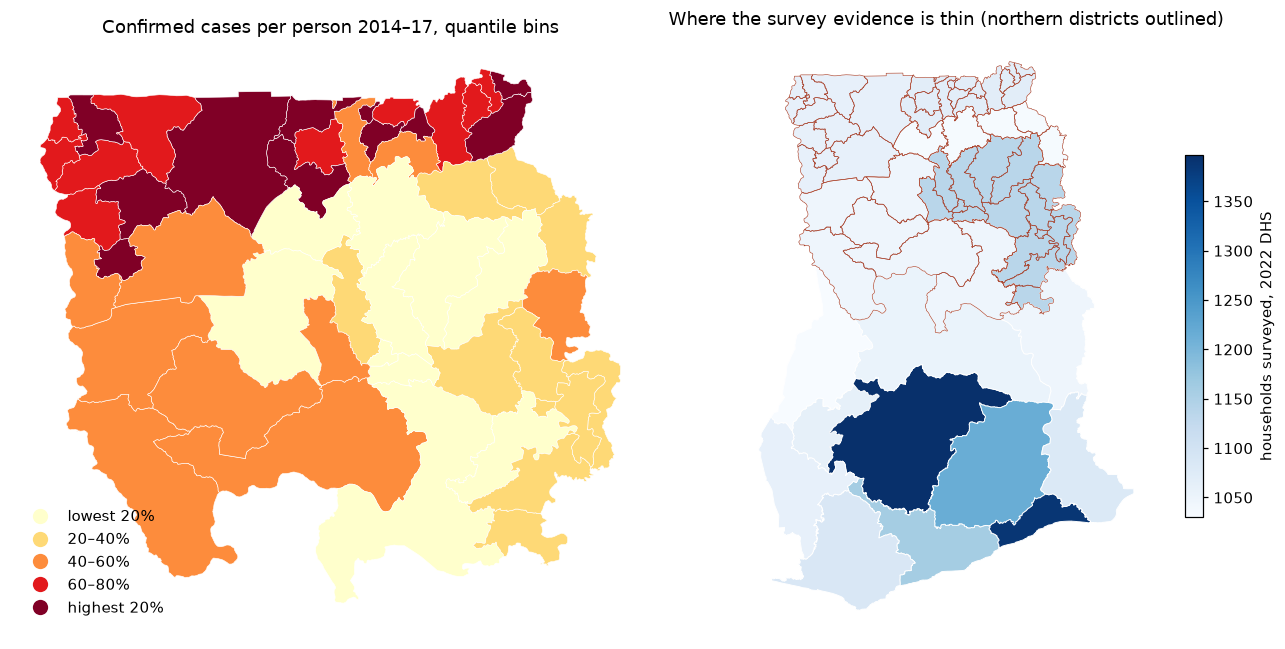

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
geo.assign(bin=pd.qcut(geo.rate, 5, labels=["lowest 20%", "20–40%", "40–60%", "60–80%", "highest 20%"])).plot(
    column="bin", cmap="YlOrRd", legend=True, edgecolor="white", linewidth=.4, ax=ax[0], legend_kwds={"loc": "lower left", "frameon": False})
ax[0].set_title("Confirmed cases per person 2014–17, quantile bins")
region_geo.plot(column="survey households", cmap="Blues", legend=True, edgecolor="white", linewidth=.6, ax=ax[1],
                legend_kwds={"label": "households surveyed, 2022 DHS", "shrink": .6})
geo.boundary.plot(ax=ax[1], color="#A8412B", linewidth=.4)
ax[1].set_title("Where the survey evidence is thin (northern districts outlined)")
for a in ax: a.set_axis_off()
plt.tight_layout(); save(fig, "05_rate_and_survey_coverage")

**Probability heatmap and data availability.** Left: the probability that a child aged 6–59 months tests positive by RDT, by region, from the 2022 DHS: the national "probability heatmap" and the only prevalence measure that covers the whole country. Right: every one of Ghana's 260 districts, shaded by whether *any* district-level case data exists for it.

districts with district-level case data: 55 of 260 (79% have none)


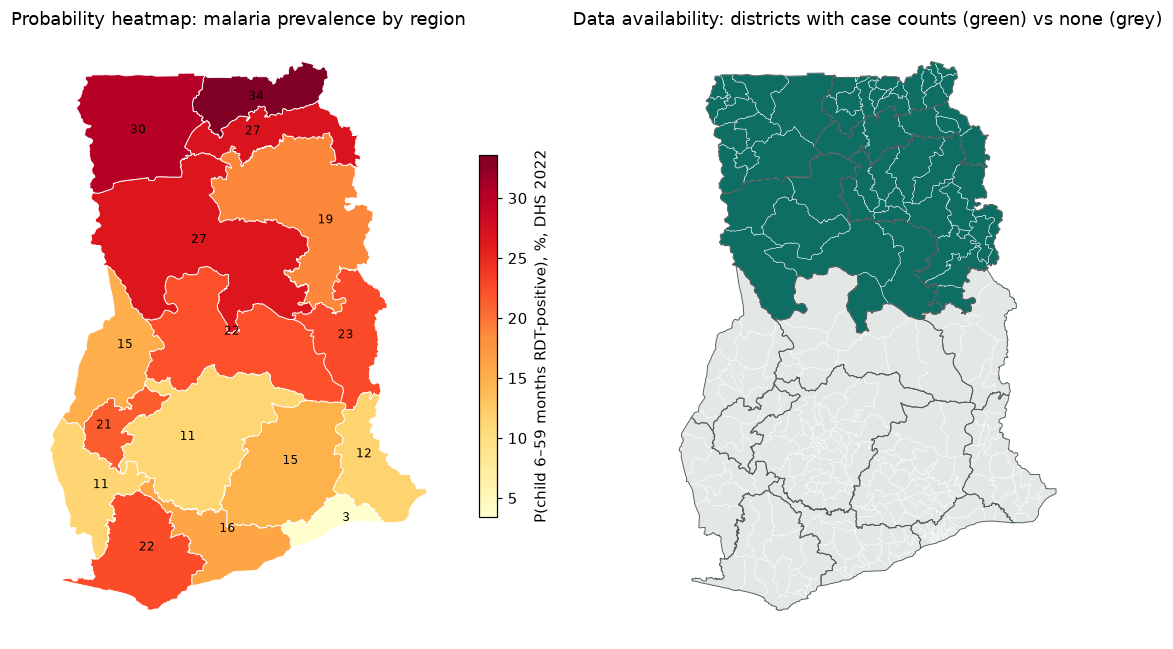

In [28]:
avail = adm2.assign(has_data=adm2.adm2_name.isin(lookup.adm2_name))
print(f"districts with district-level case data: {int(avail.has_data.sum())} of {len(avail)} "
      f"({100 * (1 - avail.has_data.mean()):.0f}% have none)")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
region_geo.plot(column="RDT prevalence 2022 %", cmap="YlOrRd", legend=True, edgecolor="white", linewidth=.6, ax=ax[0],
                legend_kwds={"label": "P(child 6–59 months RDT-positive), %, DHS 2022", "shrink": .6})
for _, r_ in region_geo.iterrows():
    p_ = r_.geometry.representative_point()
    ax[0].annotate(f"{r_['RDT prevalence 2022 %']:.0f}", (p_.x, p_.y), ha="center", fontsize=8)
ax[0].set_title("Probability heatmap: malaria prevalence by region")
avail.plot(color=avail.has_data.map({True: "#0F6E63", False: "#E3E7E5"}), edgecolor="white", linewidth=.3, ax=ax[1])
adm1.boundary.plot(ax=ax[1], color="#4F5A5B", linewidth=.6)
ax[1].set_title("Data availability: districts with case counts (green) vs none (grey)")
for a in ax: a.set_axis_off()
plt.tight_layout(); save(fig, "06_prevalence_heatmap_and_availability")

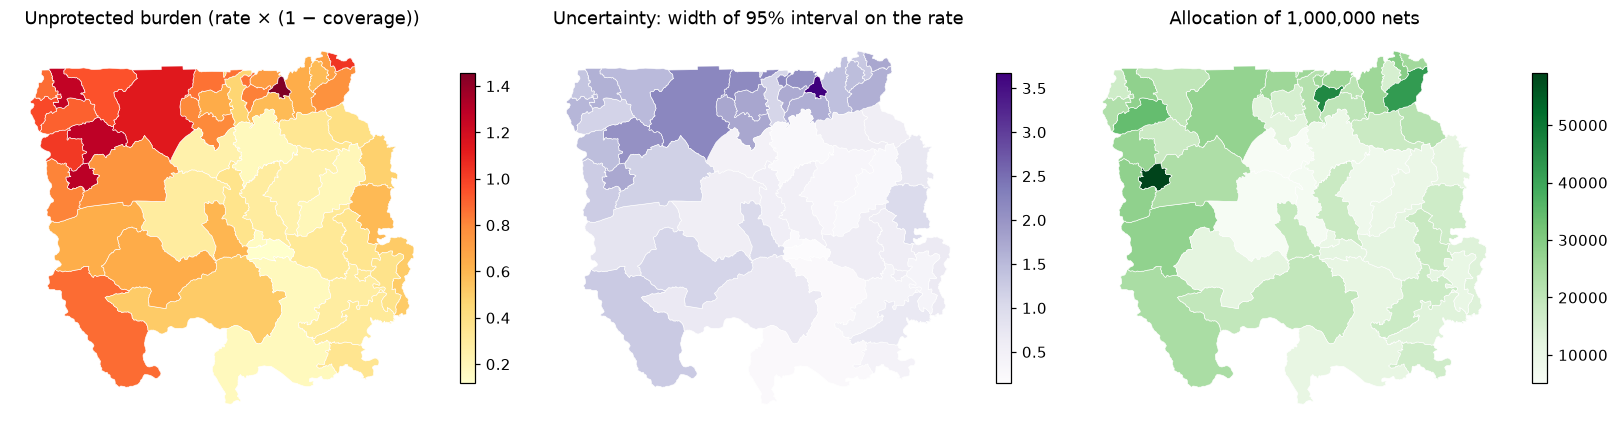

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, col, title, cmap in [(ax[0], "unprotected rate", "Unprotected burden (rate × (1 − coverage))", "YlOrRd"),
                            (ax[1], "boot width", "Uncertainty: width of 95% interval on the rate", "Purples"),
                            (ax[2], "nets", f"Allocation of {N_NETS:,} nets", "Greens")]:
    geo.plot(column=col, cmap=cmap, legend=True, edgecolor="white", linewidth=.4, ax=a, legend_kwds={"shrink": .6})
    a.set_title(title); a.set_axis_off()
plt.tight_layout(); save(fig, "07_burden_uncertainty_allocation")

**Reading the three maps together.** The burden map says where cases per unprotected person are highest. The uncertainty map says where that number is least trustworthy; wide intervals come from erratic monthly reporting, which is itself a signal of a weak health system. The allocation map is the first map scaled by population and the coverage gap. A district that is dark on both the first and the second map is exactly the case the "rank on the upper bound" rule exists for.

## 13. How much should we trust the data? (LO7)

**The headline figure.** The WHO *World Malaria Report 2024* estimates **263 million cases and 597,000 deaths** worldwide in 2023. Those are not counts. Nobody counted 263 million cases. They are outputs of a statistical model that combines routine surveillance, household surveys like the DHS, and assumptions about how many sick people never reach a facility. WHO publishes them with uncertainty intervals for that reason. The Ghana series from the WHO Global Health Observatory, in `data/raw/malaria_indicators_gha.csv`, lets us see how wide that uncertainty is for the country we are working on.

      Numeric     Low    High  interval as % of estimate
year                                                    
2014  313.800 250.800 387.800                     43.600
2017  226.200 173.200 290.200                     51.700
2022  210.800 158.500 275.300                     55.400
2023  194.900 144.200 257.300                     58.000

code  MALARIA_CONF_CASES  MALARIA_SUSPECTS  MALARIA_TOTAL_CASES  confirmed_share_of_suspected
year                                                                                         
2017               7.000            19.070               13.470                         0.370
2018               4.930            15.540               11.150                         0.320
2019               6.120            11.980                6.700                         0.510
2020               5.450            10.430                5.880                         0.520


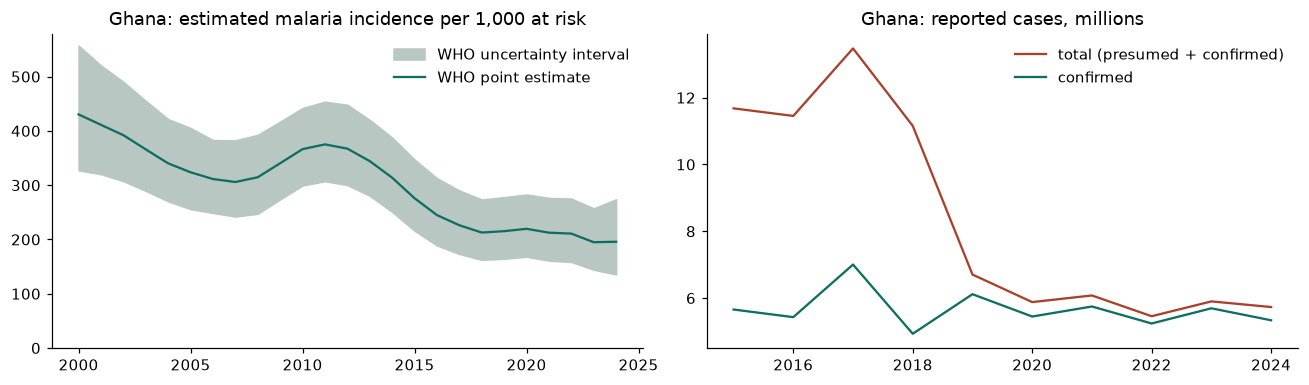

In [30]:
who = pd.read_csv(DATA / "raw/malaria_indicators_gha.csv").rename(columns={"GHO (CODE)": "code", "YEAR (DISPLAY)": "year"})
inc = who[who.code == "MALARIA_EST_INCIDENCE"].set_index("year")[["Numeric", "Low", "High"]].sort_index()
inc["interval as % of estimate"] = 100 * (inc.High - inc.Low) / inc.Numeric
counts = who[who.code.isin(["MALARIA_CONF_CASES", "MALARIA_TOTAL_CASES", "MALARIA_SUSPECTS"])].pivot_table(index="year", columns="code", values="Numeric")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].fill_between(inc.index, inc.Low, inc.High, color="#B9C7C3", label="WHO uncertainty interval")
ax[0].plot(inc.index, inc.Numeric, color="#0F6E63", label="WHO point estimate")
ax[0].set(title="Ghana: estimated malaria incidence per 1,000 at risk", ylim=(0, None)); ax[0].legend(frameon=False)
(counts[["MALARIA_TOTAL_CASES", "MALARIA_CONF_CASES"]] / 1e6).plot(ax=ax[1], color=["#A8412B", "#0F6E63"])
ax[1].set(title="Ghana: reported cases, millions", xlabel=""); ax[1].legend(["total (presumed + confirmed)", "confirmed"], frameon=False)
plt.tight_layout(); save(fig, "08_who_uncertainty")
print(inc.loc[[2014, 2017, 2022, 2023]].round(1).to_string())
print()
print((counts.loc[2017:2020] / 1e6).round(2).assign(confirmed_share_of_suspected=(counts.MALARIA_CONF_CASES / counts.MALARIA_SUSPECTS).round(2)).to_string())

**Critique, grounded in the numbers above.**

- **The interval is wide.** For Ghana the uncertainty interval spans roughly 45–60% of the point estimate in every year. A figure quoted as "195 per 1,000" could as honestly be 144 or 257. The global 263 million inherits that kind of uncertainty from every endemic country; it should be read as "a quarter of a billion, give or take tens of millions", never to three significant figures.
- **Reported counts depend on definitions, not only on disease.** Ghana's *total* reported cases fall from 11.2 million in 2018 to 6.7 million in 2019 while *confirmed* cases rise. Malaria did not halve in a year; presumed (untested) cases stopped being counted as testing became universal. Any trend that crosses that boundary is partly an artefact.
- **Surveillance sees only people who reach a facility.** Confirmed cases are between a third and a half of suspected cases, and people who never present are in neither number. The undercount is largest where facilities are furthest apart, the same remote districts our equity section worries about. That is why WHO models the estimate instead of adding up reports, and why modelled estimates exceed reported cases.
- **Deaths are less certain than cases.** Most malaria deaths in high-burden countries occur outside hospitals without a certified cause; 597,000 is derived from case estimates and assumed fatality rates, so its error compounds.

**So how much should we trust it?** Enough to say malaria is a very large problem concentrated in sub-Saharan Africa, and that Ghana's estimated incidence has fallen by more than a third since 2014. Not enough to rank districts, which is why this notebook builds its ranking from district-level data and carries an interval on every number.

**And our own data?** Described in `data/data_dictionary.md`, which serves as this project's **datasheet** in the sense of Gebru et al. (2021): it records provenance, collection method, licensing and known caveats for every file. The caveats that matter most here: district counts cover only 3 regions and 2014–17; net coverage is regional and from 2022; `positive_per_100k` is a four-year cumulative figure, not a prevalence; the survey extract is de-identified to region, so no district-level survey estimate is possible.

## 14. Limitations, sources, declarations

**What this analysis cannot claim.**
- District counts are 2014–17; the survey is 2022; net coverage is region-level. The allocation combines evidence from different years and resolutions and says so. In use, a planner would replace these with current figures.
- Routine surveillance counts *confirmed* cases at facilities. It undercounts where people do not reach facilities, which is where evidence is thinnest (§13).
- 13 regions have no district counts. The rule protects thin-evidence districts in principle; the ranked table can only rank the 50 districts we have.
- The objective is burden, not net *effectiveness*. A different objective (cases prevented per net) would give a different list.
- The total of 1,000,000 nets is our assumption. The ranking does not depend on it; the per-district counts scale with it.

**Sources for every statistic in this notebook.**

| Statistic | File | Original source |
|---|---|---|
| District case counts, population, rates (§2, §3, §6, §10, §11) | `ghana_district_cases.csv`, `raw/northern-ghana-districts-routine-data-2014-17.xlsx` | Ghana Health Service routine monthly surveillance, 2014–17 |
| Net ownership, weights, clusters, all bootstraps, supervised model (§4, §7–§9) | `ghana_mis_sample.csv` | Ghana 2022 DHS household recode, de-identified extract, licensed |
| Official net ownership and RDT prevalence by region (§4, §5, §12) | `ghana_region_malaria.csv` | DHS Program subnational indicators (STATcompiler/API) |
| Net coverage used in the allocation (§11) | `ghana_district_cases.csv` | Ghana 2022 DHS, weighted `has_net`, region level |
| Boundaries (§12) | `ghana_boundaries/gha_admin1/2.geojson` | HDX / COD administrative boundaries, 2021 |
| Ghana incidence and reported cases (§13) | `raw/malaria_indicators_gha.csv` | WHO Global Health Observatory |
| 263 million cases, 597,000 deaths (§13) | cited | WHO, *World Malaria Report 2024* |
| Datasheet | `data/data_dictionary.md` | Course data package; format after Gebru et al., *Datasheets for Datasets*, CACM 2021 |

**Submission checklist.**
- No cell fits, encodes or scales on pooled train+test data, except the labelled "leaky" rows of the audit in §9.
- §9 names each leak risk with a before/after number.
- Every statistic cites a source (table above); the datasheet is referenced (§13).
- AI-use declaration: in each member's individual reflection, submitted separately.
- Runs top to bottom from a fresh clone: `README.md` has the four commands.

**Data rules.** `data/` is git-ignored and never committed. This notebook and everything in `outputs/` contain aggregates only: no household rows.